<a href="https://www.kaggle.com/code/adegbaju/parkinson-s-disease-ml-dl-agentic-ai?scriptVersionId=310966964" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

 
 # Parkinson's Disease Telemonitoring - ML/DL & Agentic AI Analysis
 
 **Dataset**: Oxford Parkinson's Disease Telemonitoring Dataset
 **Goal**: Predict motor_UPDRS and total_UPDRS from voice measurements

 This notebook demonstrates:
 1. Exploratory Data Analysis (EDA)
 2. Traditional Machine Learning Models
 3. Deep Learning Approaches
 4. Agentic AI Framework for Automated Model Selection


##  Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


2026-04-12 11:12:26.991761: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775992347.175252      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775992347.228823      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775992347.632968      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775992347.633005      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775992347.633008      23 computation_placer.cc:177] computation placer alr

##  Data Loading and Initial Exploration


In [2]:
 # Load the dataset
df = pd.read_csv('/kaggle/input/datasets/porinitahoque/parkinsons-telemonitoring/Parkinsons-Telemonitoring-ucirvine.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (5875, 22)

First 5 rows:


,subject,age,sex,test_time,motor_updrs,total_updrs,jitter,jitter_abs,jitter_rap,jitter_ppq5,...,shimmer_db,shimmer_apq3,shimmer_apq5,shimmer_apq11,shimmer_dda,nhr,hnr,rpde,dfa,ppe
0,1,72,False,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,False,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,False,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,False,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,False,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [3]:
# Rename columns for easier access
df.columns = ['subject_id', 'age', 'sex', 'test_time', 'motor_updrs', 'total_updrs',
              'jitter_percent', 'jitter_abs', 'jitter_rap', 'jitter_ppq5', 'jitter_ddp',
              'shimmer', 'shimmer_db', 'shimmer_apq3', 'shimmer_apq5', 
              'shimmer_apq11', 'shimmer_dda', 'nhr', 'hnr', 'rpde', 'dfa', 'ppe']

print("Dataset Info:")
df.info()

print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   subject_id      5875 non-null   int64  
 1   age             5875 non-null   int64  
 2   sex             5875 non-null   bool   
 3   test_time       5875 non-null   float64
 4   motor_updrs     5875 non-null   float64
 5   total_updrs     5875 non-null   float64
 6   jitter_percent  5875 non-null   float64
 7   jitter_abs      5875 non-null   float64
 8   jitter_rap      5875 non-null   float64
 9   jitter_ppq5     5875 non-null   float64
 10  jitter_ddp      5875 non-null   float64
 11  shimmer         5875 non-null   float64
 12  shimmer_db      5875 non-null   float64
 13  shimmer_apq3    5875 non-null   float64
 14  shimmer_apq5    5875 non-null   float64
 15  shimmer_apq11   5875 non-null   float64
 16  shimmer_dda     5875 non-null   float64
 17  nhr             587

,subject_id,age,test_time,motor_updrs,total_updrs,jitter_percent,jitter_abs,jitter_rap,jitter_ppq5,jitter_ddp,...,shimmer_db,shimmer_apq3,shimmer_apq5,shimmer_apq11,shimmer_dda,nhr,hnr,rpde,dfa,ppe
count,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,...,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000
mean,21.494128,64.804936,92.863722,21.296229,29.018942,0.006154,0.000044,0.002987,0.003277,0.008962,...,0.310960,0.017156,0.020144,0.027481,0.051467,0.032120,21.679495,0.541473,0.653240,0.219589
std,12.372279,8.821524,53.445602,8.129282,10.700283,0.005624,0.000036,0.003124,0.003732,0.009371,...,0.230254,0.013237,0.016664,0.019986,0.039711,0.059692,4.291096,0.100986,0.070902,0.091498
min,1.000000,36.000000,-4.262500,5.037700,7.000000,0.000830,0.000002,0.000330,0.000430,0.000980,...,0.026000,0.001610,0.001940,0.002490,0.004840,0.000286,1.659000,0.151020,0.514040,0.021983
25%,10.000000,58.000000,46.847500,15.000000,21.371000,0.003580,0.000022,0.001580,0.001820,0.004730,...,0.175000,0.009280,0.010790,0.015665,0.027830,0.010955,19.406000,0.469785,0.596180,0.156340
50%,22.000000,65.000000,91.523000,20.871000,27.576000,0.004900,0.000035,0.002250,0.002490,0.006750,...,0.253000,0.013700,0.015940,0.022710,0.041110,0.018448,21.920000,0.542250,0.643600,0.205500
75%,33.000000,72.000000,138.445000,27.596500,36.399000,0.006800,0.000053,0.003290,0.003460,0.009870,...,0.365000,0.020575,0.023755,0.032715,0.061735,0.031463,24.444000,0.614045,0.711335,0.264490
max,42.000000,85.000000,215.490000,39.511000,54.992000,0.099990,0.000446,0.057540,0.069560,0.172630,...,2.107000,0.162670,0.167020,0.275460,0.488020,0.748260,37.875000,0.966080,0.865600,0.731730


In [4]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())


Missing Values:
subject_id        0
age               0
sex               0
test_time         0
motor_updrs       0
total_updrs       0
jitter_percent    0
jitter_abs        0
jitter_rap        0
jitter_ppq5       0
jitter_ddp        0
shimmer           0
shimmer_db        0
shimmer_apq3      0
shimmer_apq5      0
shimmer_apq11     0
shimmer_dda       0
nhr               0
hnr               0
rpde              0
dfa               0
ppe               0
dtype: int64


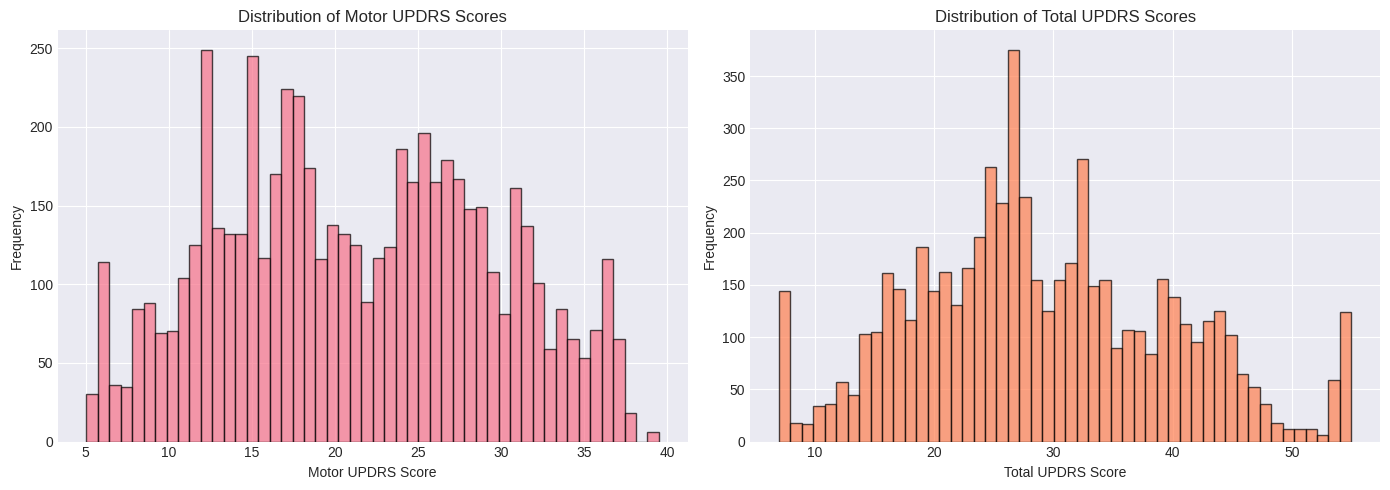

Motor UPDRS - Mean: 21.30, Std: 8.13
Total UPDRS - Mean: 29.02, Std: 10.70


In [5]:
# Visualize target distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['motor_updrs'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Motor UPDRS Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Motor UPDRS Scores')

axes[1].hist(df['total_updrs'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Total UPDRS Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Total UPDRS Scores')

plt.tight_layout()
plt.show()


print(f"Motor UPDRS - Mean: {df['motor_updrs'].mean():.2f}, Std: {df['motor_updrs'].std():.2f}")
print(f"Total UPDRS - Mean: {df['total_updrs'].mean():.2f}, Std: {df['total_updrs'].std():.2f}")

##  Exploratory Data Analysis (EDA)

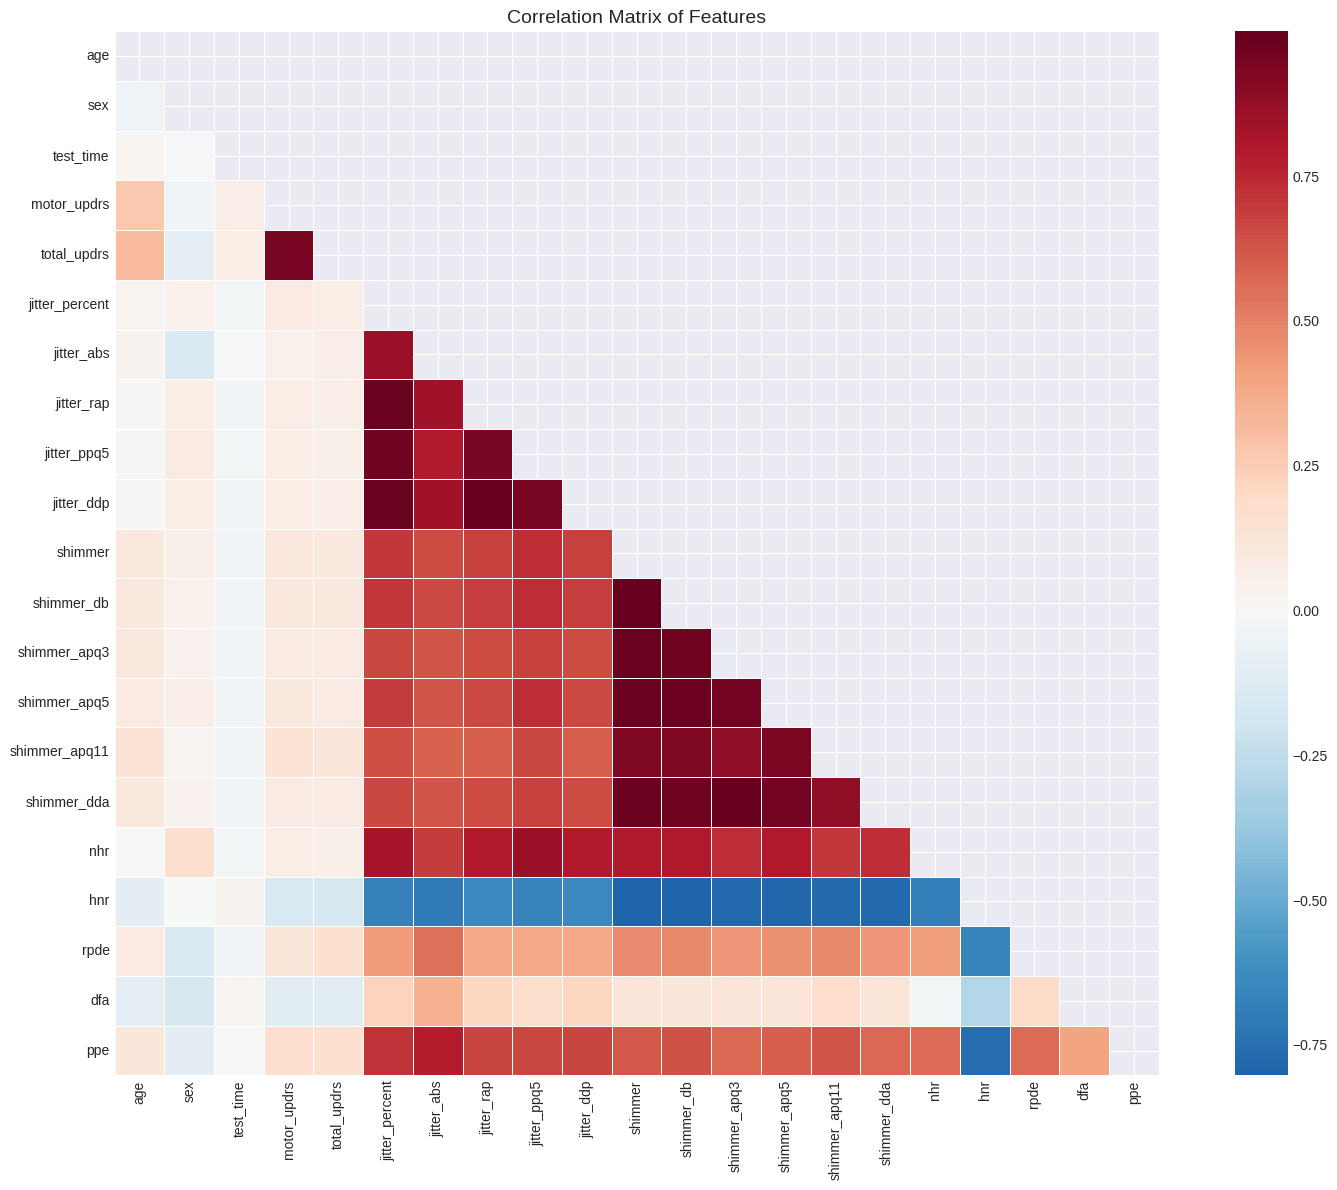

In [6]:
# Correlation matrix
plt.figure(figsize=(16, 12))
correlation_matrix = df.drop(['subject_id'], axis=1).corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Features', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# Top correlations with targets
target_corr = correlation_matrix[['motor_updrs', 'total_updrs']].sort_values('motor_updrs', ascending=False)
print("Top 10 Features Correlated with Motor UPDRS:")
print(target_corr['motor_updrs'].head(10))
print("\nTop 10 Features Correlated with Total UPDRS:")
print(target_corr['total_updrs'].head(10))


Top 10 Features Correlated with Motor UPDRS:
motor_updrs       1.000000
total_updrs       0.947231
age               0.273665
ppe               0.162433
shimmer_apq11     0.136560
rpde              0.128607
shimmer_db        0.110076
shimmer           0.102349
shimmer_apq5      0.092105
jitter_percent    0.084816
Name: motor_updrs, dtype: float64

Top 10 Features Correlated with Total UPDRS:
motor_updrs       0.947231
total_updrs       1.000000
age               0.310290
ppe               0.156195
shimmer_apq11     0.120838
rpde              0.156897
shimmer_db        0.098790
shimmer           0.092141
shimmer_apq5      0.083467
jitter_percent    0.074247
Name: total_updrs, dtype: float64


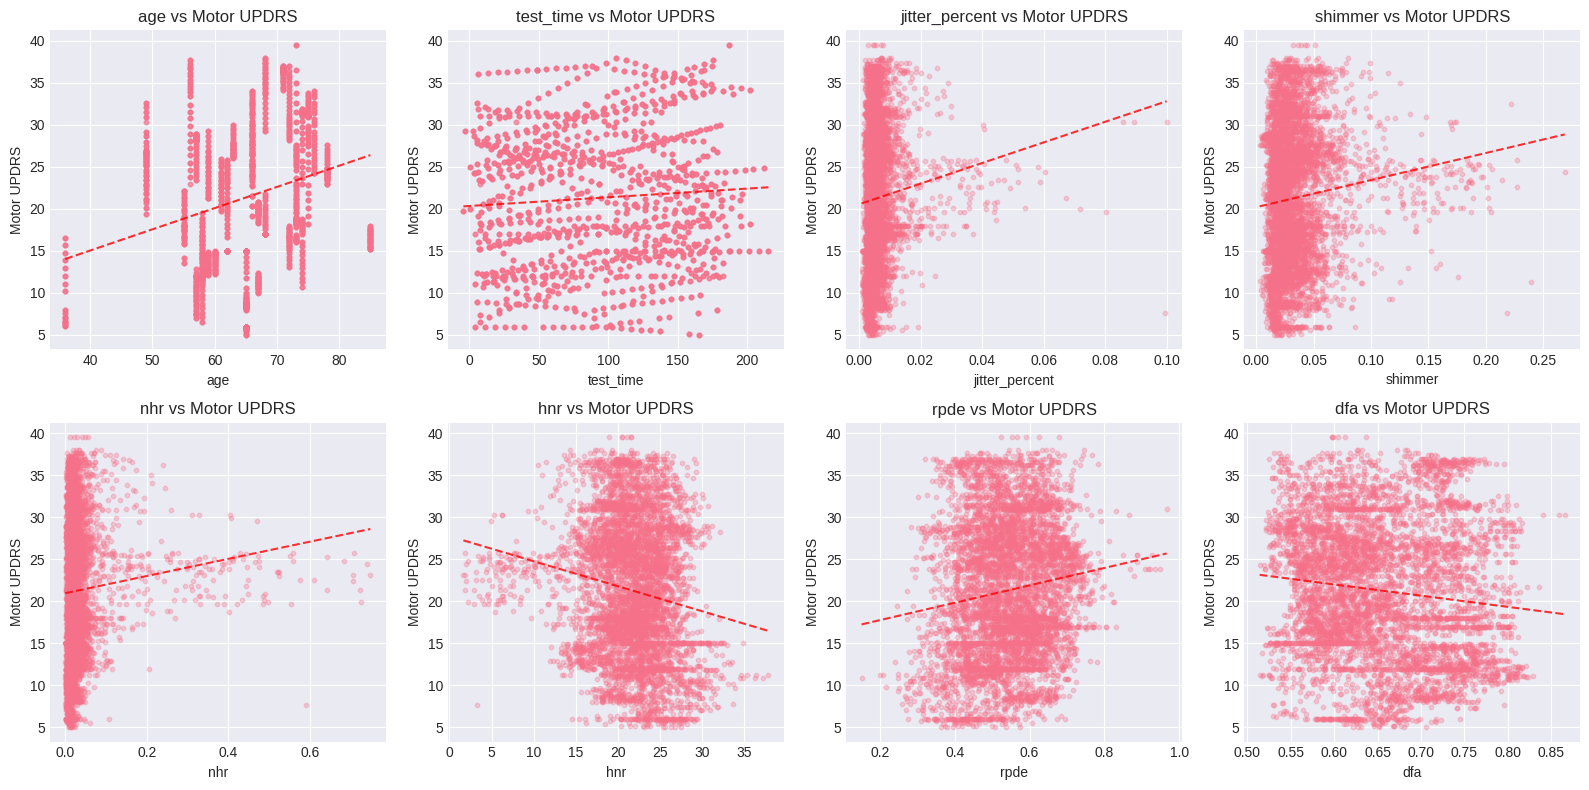

In [8]:
# Visualize feature relationships with targets
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
top_features = ['age', 'test_time', 'jitter_percent', 'shimmer', 'nhr', 'hnr', 'rpde', 'dfa']

for idx, feature in enumerate(top_features):
    row, col = idx // 4, idx % 4
    axes[row, col].scatter(df[feature], df['motor_updrs'], alpha=0.3, s=10)
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Motor UPDRS')
    axes[row, col].set_title(f'{feature} vs Motor UPDRS')
    
    # Add trend line
    z = np.polyfit(df[feature], df['motor_updrs'], 1)
    p = np.poly1d(z)
    axes[row, col].plot(df[feature].sort_values(), 
                        p(df[feature].sort_values()), 
                        "r--", alpha=0.8)

plt.tight_layout()
plt.show()

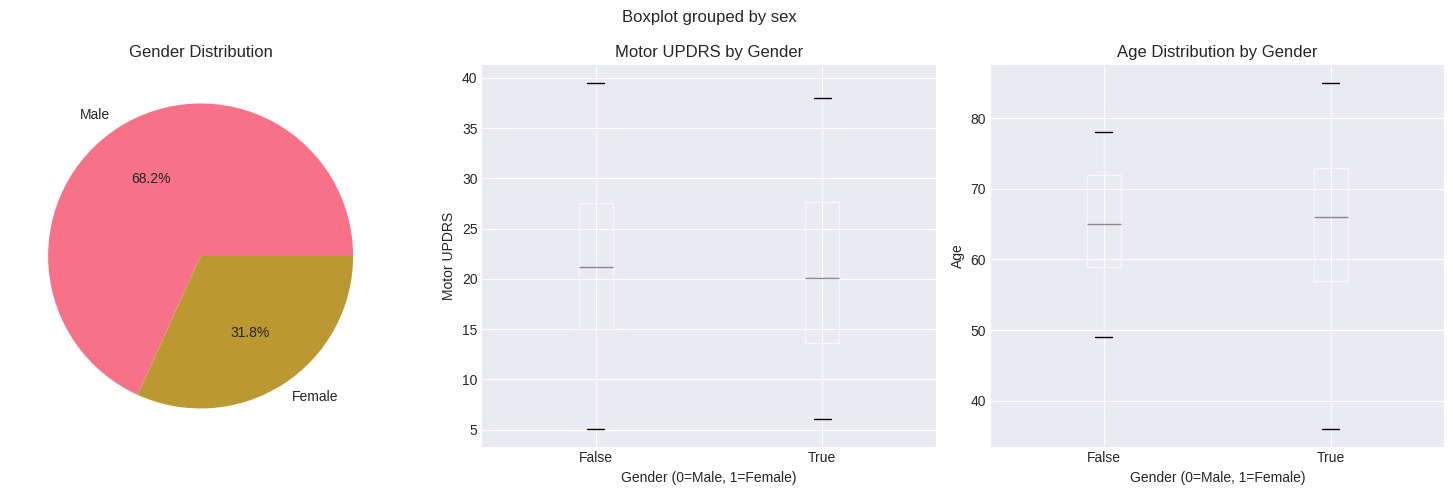

In [9]:
# Gender analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gender distribution
gender_counts = df['sex'].value_counts()
axes[0].pie(gender_counts.values, labels=['Male', 'Female'], autopct='%1.1f%%')
axes[0].set_title('Gender Distribution')

# Motor UPDRS by gender
df.boxplot(column='motor_updrs', by='sex', ax=axes[1])
axes[1].set_title('Motor UPDRS by Gender')
axes[1].set_xlabel('Gender (0=Male, 1=Female)')
axes[1].set_ylabel('Motor UPDRS')

# Age distribution by gender
df.boxplot(column='age', by='sex', ax=axes[2])
axes[2].set_title('Age Distribution by Gender')
axes[2].set_xlabel('Gender (0=Male, 1=Female)')
axes[2].set_ylabel('Age')

plt.tight_layout()
plt.show()

In [10]:
# Subject-wise analysis
subject_stats = df.groupby('subject_id').agg({
    'motor_updrs': ['mean', 'std', 'count'],
    'total_updrs': ['mean', 'std'],
    'age': 'first',
    'sex': 'first'
}).round(2)

subject_stats.columns = ['motor_mean', 'motor_std', 'recordings', 'total_mean', 'total_std', 'age', 'sex']
subject_stats = subject_stats.reset_index()

print("Subject-wise Statistics:")
subject_stats.head(10)

Subject-wise Statistics:


,subject_id,motor_mean,motor_std,recordings,total_mean,total_std,age,sex
0,1,31.90,2.67,149,40.73,4.07,72,False
1,2,13.81,2.43,145,16.28,2.47,58,False
2,3,27.12,1.74,144,33.36,4.35,57,False
3,4,15.79,2.54,137,23.59,4.04,74,False
4,5,31.63,0.91,156,41.85,1.62,75,False
5,6,27.53,1.09,156,41.34,2.21,63,False
6,7,16.05,1.30,161,23.07,1.66,72,False
7,8,19.89,1.59,150,25.89,1.59,73,True
8,9,18.31,1.60,152,25.08,1.12,68,False
9,10,13.42,1.67,148,19.85,1.00,58,False


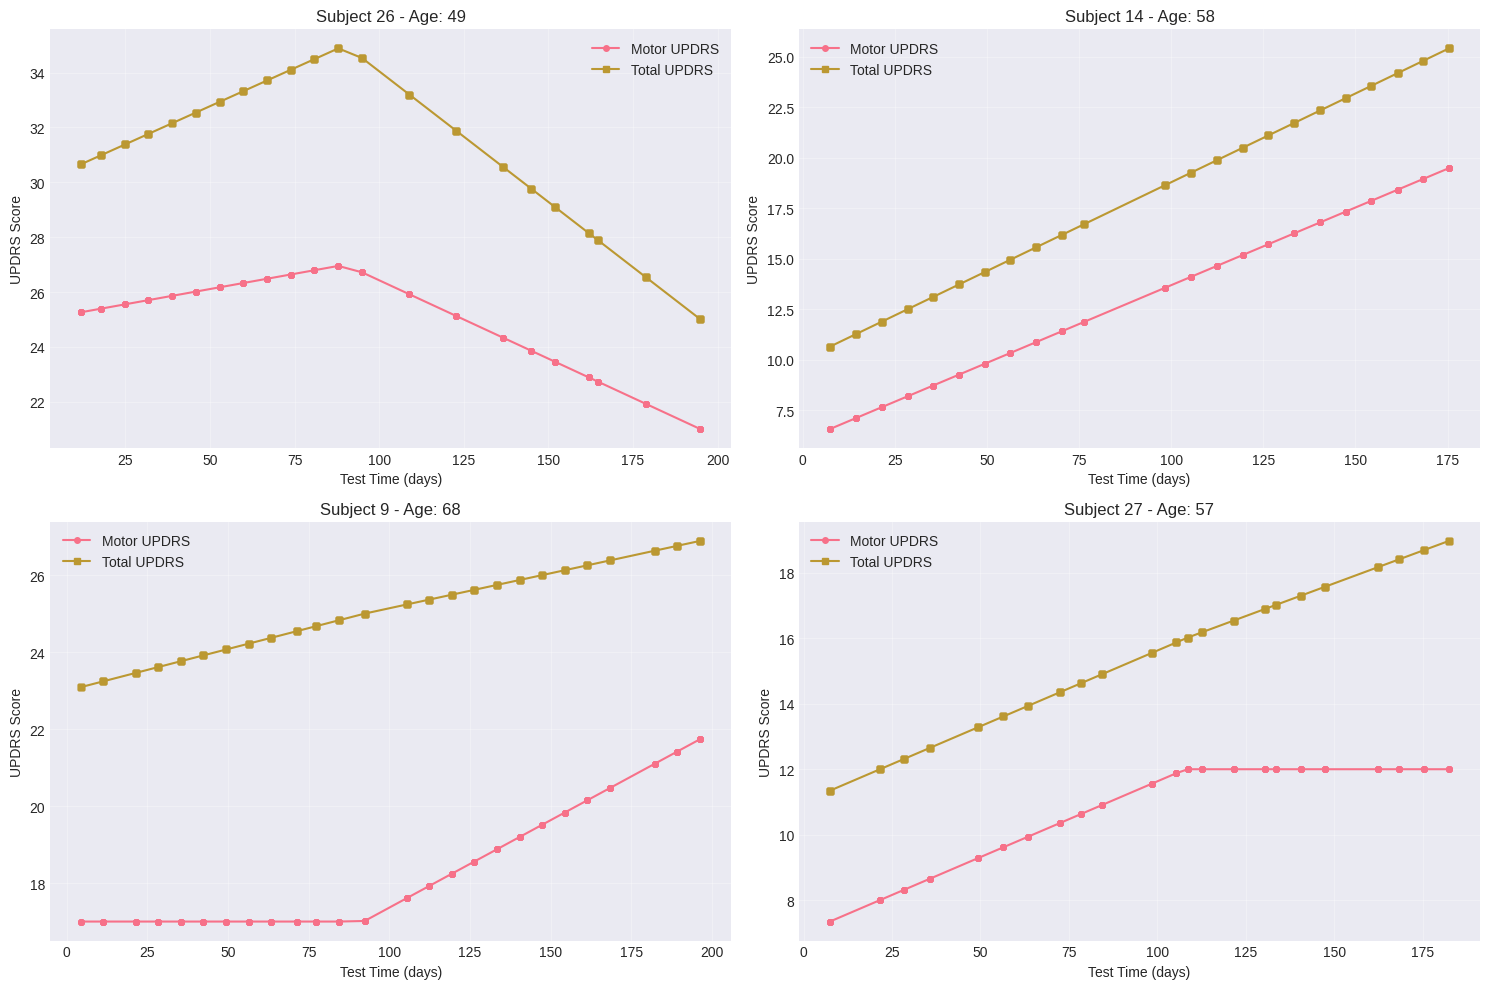

In [11]:
# Visualize subject trajectories
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Select random subjects for visualization
sample_subjects = np.random.choice(df['subject_id'].unique(), 4, replace=False)

for idx, subject_id in enumerate(sample_subjects):
    row, col = idx // 2, idx % 2
    subject_data = df[df['subject_id'] == subject_id].sort_values('test_time')
    
    axes[row, col].plot(subject_data['test_time'], subject_data['motor_updrs'], 
                       'o-', label='Motor UPDRS', markersize=4)
    axes[row, col].plot(subject_data['test_time'], subject_data['total_updrs'], 
                       's-', label='Total UPDRS', markersize=4)
    axes[row, col].set_xlabel('Test Time (days)')
    axes[row, col].set_ylabel('UPDRS Score')
    axes[row, col].set_title(f'Subject {subject_id} - Age: {subject_data["age"].iloc[0]}')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 ##  Feature Engineering


In [12]:
def create_features(df):
    """Create additional features for better prediction"""
    df_feat = df.copy()
    
    # Interaction features
    df_feat['age_test_interaction'] = df_feat['age'] * df_feat['test_time'] / 100
    
    # Jitter aggregations
    jitter_cols = ['jitter_percent', 'jitter_abs', 'jitter_rap', 'jitter_ppq5', 'jitter_ddp']
    df_feat['jitter_mean'] = df_feat[jitter_cols].mean(axis=1)
    df_feat['jitter_std'] = df_feat[jitter_cols].std(axis=1)
    df_feat['jitter_range'] = df_feat[jitter_cols].max(axis=1) - df_feat[jitter_cols].min(axis=1)
    
    # Shimmer aggregations
    shimmer_cols = ['shimmer', 'shimmer_db', 'shimmer_apq3', 'shimmer_apq5', 
                    'shimmer_apq11', 'shimmer_dda']
    df_feat['shimmer_mean'] = df_feat[shimmer_cols].mean(axis=1)
    df_feat['shimmer_std'] = df_feat[shimmer_cols].std(axis=1)
    
    # Noise ratio features
    df_feat['noise_ratio'] = df_feat['nhr'] / (df_feat['hnr'] + 1e-10)
    df_feat['hnr_normalized'] = 1 / (df_feat['hnr'] + 1e-10)
    
    # Complexity measures
    df_feat['complexity_index'] = (df_feat['rpde'] + df_feat['dfa'] + df_feat['ppe']) / 3
    
    # Polynomial features for important predictors
    df_feat['age_squared'] = df_feat['age'] ** 2
    df_feat['test_time_squared'] = df_feat['test_time'] ** 2
    
    return df_feat

# Apply feature engineering
df_enhanced = create_features(df)
print(f"Original features: {df.shape[1]}")
print(f"Enhanced features: {df_enhanced.shape[1]}")


Original features: 22
Enhanced features: 33


##  Prepare Data for Modeling

In [13]:
# Define features to use for modeling
base_features = ['age', 'sex', 'test_time', 
                'jitter_percent', 'jitter_abs', 'jitter_rap', 'jitter_ppq5', 'jitter_ddp',
                'shimmer', 'shimmer_db', 'shimmer_apq3', 'shimmer_apq5', 'shimmer_apq11', 'shimmer_dda',
                'nhr', 'hnr', 'rpde', 'dfa', 'ppe']

engineered_features = ['age_test_interaction', 'jitter_mean', 'jitter_std', 'jitter_range',
                      'shimmer_mean', 'shimmer_std', 'noise_ratio', 'hnr_normalized',
                      'complexity_index', 'age_squared', 'test_time_squared']

# Combine all features
all_features = base_features + engineered_features

# Prepare X and y
X = df_enhanced[all_features]
y_motor = df_enhanced['motor_updrs']
y_total = df_enhanced['total_updrs']

# Split data (respecting subject grouping for realistic evaluation)
subject_ids = df_enhanced['subject_id'].unique()
train_subjects, test_subjects = train_test_split(subject_ids, test_size=0.2, random_state=42)
train_subjects, val_subjects = train_test_split(train_subjects, test_size=0.2, random_state=42)

train_mask = df_enhanced['subject_id'].isin(train_subjects)
val_mask = df_enhanced['subject_id'].isin(val_subjects)
test_mask = df_enhanced['subject_id'].isin(test_subjects)

X_train, X_val, X_test = X[train_mask], X[val_mask], X[test_mask]
y_motor_train, y_motor_val, y_motor_test = y_motor[train_mask], y_motor[val_mask], y_motor[test_mask]
y_total_train, y_total_val, y_total_test = y_total[train_mask], y_total[val_mask], y_total[test_mask]

print(f"Training set: {X_train.shape[0]} samples ({len(train_subjects)} subjects)")
print(f"Validation set: {X_val.shape[0]} samples ({len(val_subjects)} subjects)")
print(f"Test set: {X_test.shape[0]} samples ({len(test_subjects)} subjects)")


Training set: 3673 samples (26 subjects)
Validation set: 967 samples (7 subjects)
Test set: 1235 samples (9 subjects)


In [14]:
# Scale features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=all_features, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=all_features, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=all_features, index=X_test.index)

##  Traditional Machine Learning Models

Training Models for Motor UPDRS Prediction

Ridge Regression:
  Train R²: 0.2677, Val R²: -0.3569
  Train MAE: 6.1177, Val MAE: 7.2415

Lasso Regression:
  Train R²: 0.2658, Val R²: -0.3188
  Train MAE: 6.1442, Val MAE: 7.1579

ElasticNet:
  Train R²: 0.2630, Val R²: -0.2705
  Train MAE: 6.1671, Val MAE: 7.0674

Random Forest:
  Train R²: 0.9679, Val R²: -0.1397
  Train MAE: 0.7970, Val MAE: 6.5371

Gradient Boosting:
  Train R²: 0.9783, Val R²: -0.4413
  Train MAE: 0.8519, Val MAE: 7.5124

SVR:
  Train R²: 0.2783, Val R²: -0.0359
  Train MAE: 5.7917, Val MAE: 6.3809

Motor UPDRS Model Comparison
            Model  Train MSE   Val MSE  Train MAE  Val MAE  Train R2    Val R2
 Ridge Regression  50.798748 81.158704   6.117731 7.241534  0.267743 -0.356921
 Lasso Regression  50.936531 78.877140   6.144214 7.157907  0.265757 -0.318775
       ElasticNet  51.130945 75.990883   6.167131 7.067363  0.262954 -0.270519
    Random Forest   2.226824 68.169255   0.796985 6.537071  0.967901 -0.139746
G

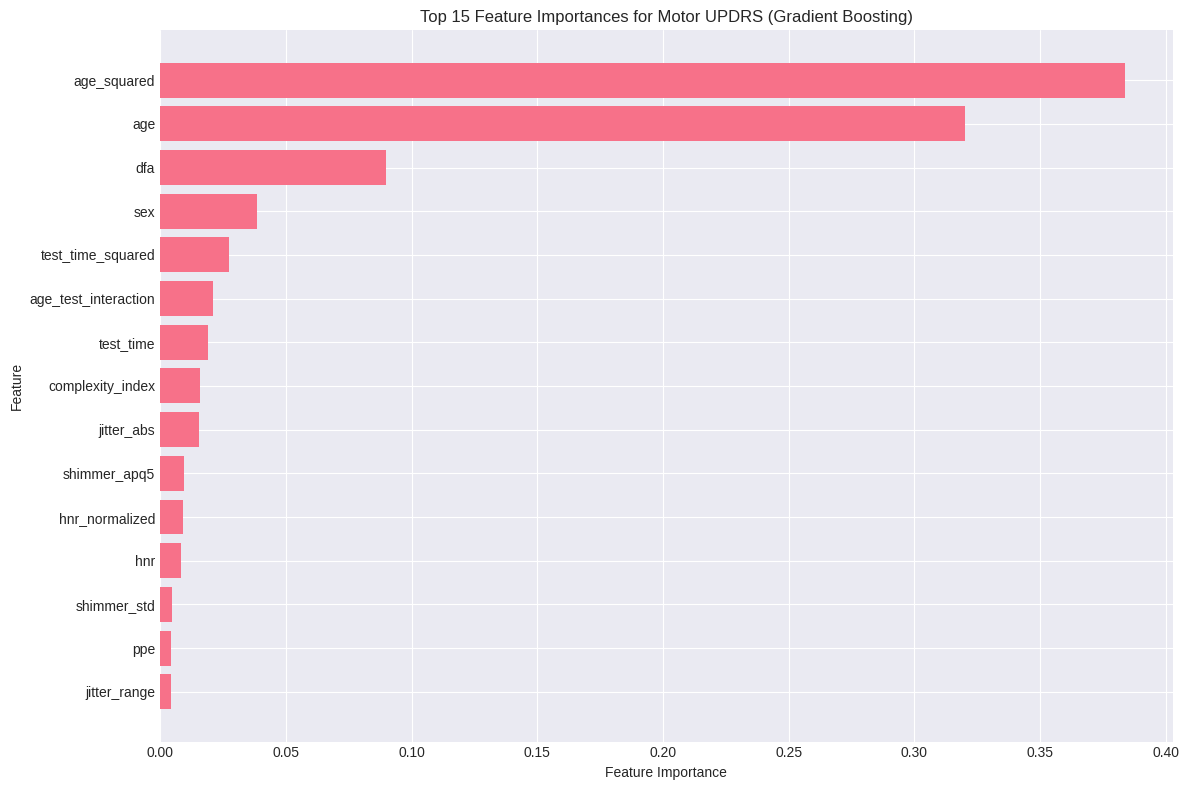

In [15]:
def evaluate_model(model, X_train, X_val, y_train, y_val, model_name):
    """Evaluate a model and return metrics"""
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    metrics = {
        'Model': model_name,
        'Train MSE': mean_squared_error(y_train, y_train_pred),
        'Val MSE': mean_squared_error(y_val, y_val_pred),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Val MAE': mean_absolute_error(y_val, y_val_pred),
        'Train R2': r2_score(y_train, y_train_pred),
        'Val R2': r2_score(y_val, y_val_pred)
    }
    
    return metrics, model


# Train multiple models for Motor UPDRS
print("=" * 60)
print("Training Models for Motor UPDRS Prediction")
print("=" * 60)

models_motor = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

results_motor = []
trained_models_motor = {}

for name, model in models_motor.items():
    metrics, trained_model = evaluate_model(model, X_train_scaled, X_val_scaled, 
                                           y_motor_train, y_motor_val, name)
    results_motor.append(metrics)
    trained_models_motor[name] = trained_model
    print(f"\n{name}:")
    print(f"  Train R²: {metrics['Train R2']:.4f}, Val R²: {metrics['Val R2']:.4f}")
    print(f"  Train MAE: {metrics['Train MAE']:.4f}, Val MAE: {metrics['Val MAE']:.4f}")

# Results DataFrame
results_motor_df = pd.DataFrame(results_motor)
print("\n" + "=" * 60)
print("Motor UPDRS Model Comparison")
print("=" * 60)
print(results_motor_df.to_string(index=False))


# Feature importance from best models
best_model_motor = trained_models_motor['Gradient Boosting']

feature_importance = pd.DataFrame({
    'feature': all_features,
    'importance': best_model_motor.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances for Motor UPDRS (Gradient Boosting)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

##  Deep Learning Models


Training Deep Learning Models...


I0000 00:00:1775992390.390790      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775992390.396634      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/100


I0000 00:00:1775992394.398831      72 service.cc:152] XLA service 0x7d0194009ba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775992394.398865      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775992394.398869      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775992394.951949      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


 63/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21.2955 - mae: 21.7955 - mse: 548.2683

I0000 00:00:1775992398.010246      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - loss: 21.1035 - mae: 21.6034 - mse: 539.5478 - val_loss: 19.2838 - val_mae: 19.7838 - val_mse: 452.5007 - learning_rate: 0.0010
Epoch 2/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19.7370 - mae: 20.2365 - mse: 483.4649 - val_loss: 16.7550 - val_mae: 17.2550 - val_mse: 357.3836 - learning_rate: 0.0010
Epoch 3/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16.9526 - mae: 17.4499 - mse: 380.5093 - val_loss: 13.0810 - val_mae: 13.5793 - val_mse: 245.4261 - learning_rate: 0.0010
Epoch 4/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12.5846 - mae: 13.0798 - mse: 235.3682 - val_loss: 8.0066 - val_mae: 8.4915 - val_mse: 123.3894 - learning_rate: 0.0010
Epoch 5/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.5954 - mae: 9.0835 - mse: 125.5082 - val_loss: 6.2331 - val_mae: 6.7220 - val_mse: 80.9616 - learning_rate: 0.0010
Epoch 6/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.8192 - mae: 7.3025 - mse: 82.8280 - val

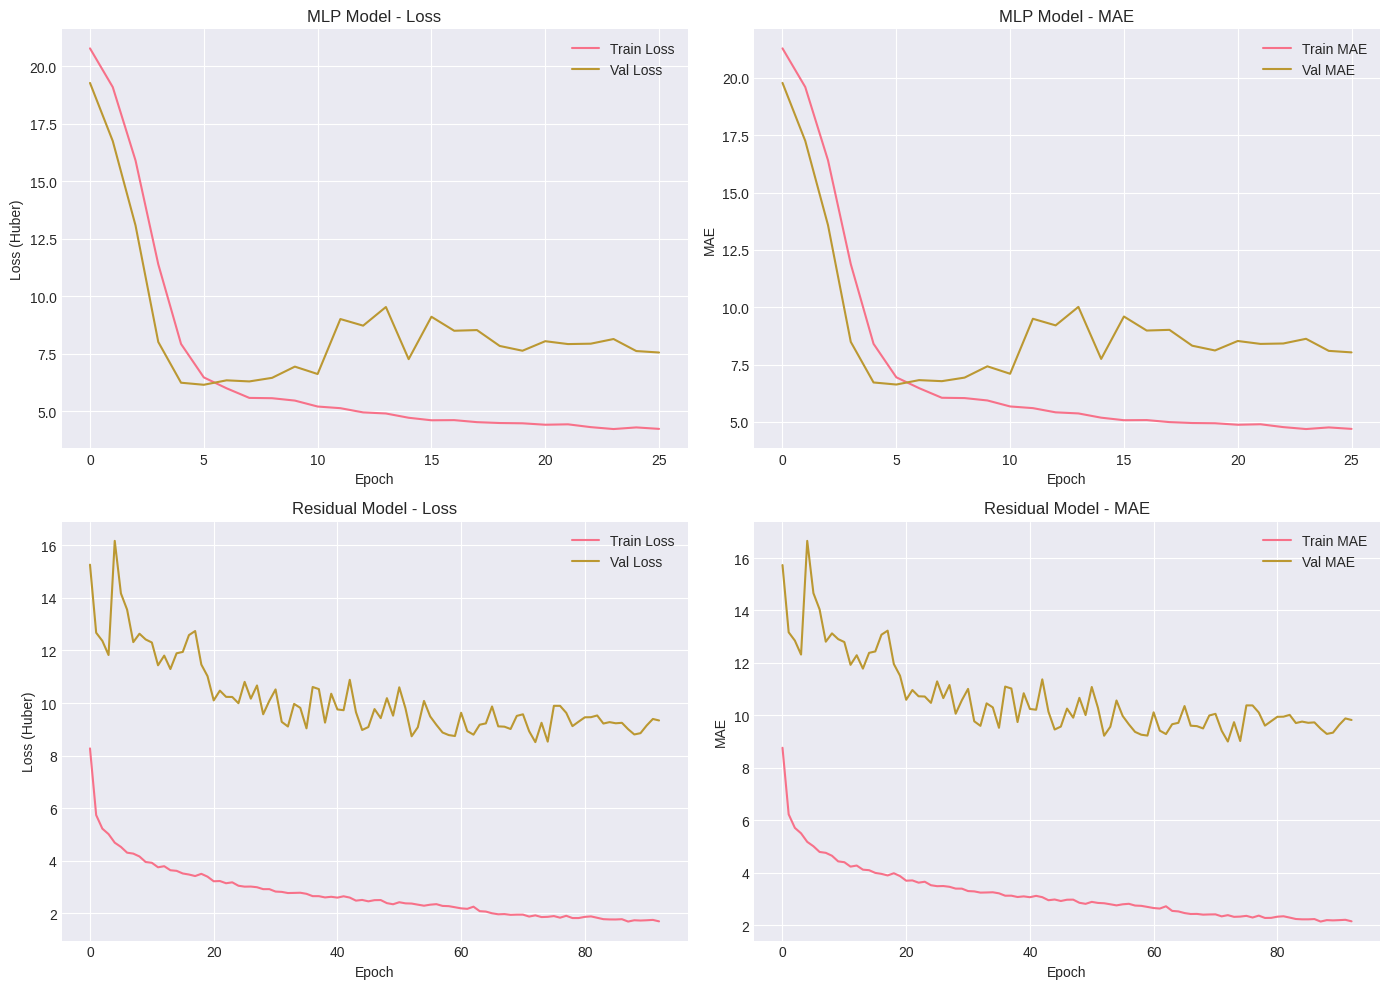


Deep Learning Model Results:
             Model  Train MSE    Val MSE  Train MAE  Val MAE  Train R2    Val R2
MLP Neural Network  51.968410  74.496812    5.82622 6.631874  0.250882 -0.245539
  Residual Network  10.099858 206.640845    1.62787 8.999278  0.854412 -2.454902


In [16]:
def create_mlp_model(input_dim, layers_config=[256, 128, 64, 32], dropout_rate=0.3):
    """Create a Multi-Layer Perceptron model"""
    model = models.Sequential()
    
    # Input layer
    model.add(layers.Dense(layers_config[0], activation='relu', input_shape=(input_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout_rate))
    
    # Hidden layers
    for units in layers_config[1:]:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))
    
    # Output layer
    model.add(layers.Dense(1))
    
    return model

def create_residual_model(input_dim):
    """Create a residual network for regression"""
    inputs = layers.Input(shape=(input_dim,))
    
    # Initial dense layer
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    
    # Residual blocks
    for _ in range(3):
        residual = x
        x = layers.Dense(128, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.2)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Add()([x, residual])
        x = layers.Activation('relu')(x)
    
    # Output
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1)(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    return model


# Train Deep Learning Models for Motor UPDRS
print("Training Deep Learning Models...")

# MLP Model
mlp_model = create_mlp_model(X_train_scaled.shape[1])
mlp_model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss=Huber(), 
                  metrics=['mae', 'mse'])

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)

# Train
history_mlp = mlp_model.fit(
    X_train_scaled, y_motor_train,
    validation_data=(X_val_scaled, y_motor_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


# Residual Model
residual_model = create_residual_model(X_train_scaled.shape[1])
residual_model.compile(optimizer=Adam(learning_rate=0.001),
                       loss=Huber(),
                       metrics=['mae', 'mse'])

history_residual = residual_model.fit(
    X_train_scaled, y_motor_train,
    validation_data=(X_val_scaled, y_motor_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MLP Model
axes[0, 0].plot(history_mlp.history['loss'], label='Train Loss')
axes[0, 0].plot(history_mlp.history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (Huber)')
axes[0, 0].set_title('MLP Model - Loss')
axes[0, 0].legend()

axes[0, 1].plot(history_mlp.history['mae'], label='Train MAE')
axes[0, 1].plot(history_mlp.history['val_mae'], label='Val MAE')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].set_title('MLP Model - MAE')
axes[0, 1].legend()

# Residual Model
axes[1, 0].plot(history_residual.history['loss'], label='Train Loss')
axes[1, 0].plot(history_residual.history['val_loss'], label='Val Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss (Huber)')
axes[1, 0].set_title('Residual Model - Loss')
axes[1, 0].legend()

axes[1, 1].plot(history_residual.history['mae'], label='Train MAE')
axes[1, 1].plot(history_residual.history['val_mae'], label='Val MAE')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('MAE')
axes[1, 1].set_title('Residual Model - MAE')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


# Evaluate Deep Learning Models
def evaluate_dl_model(model, X_train, X_val, y_train, y_val, model_name):
    y_train_pred = model.predict(X_train, verbose=0).flatten()
    y_val_pred = model.predict(X_val, verbose=0).flatten()
    
    return {
        'Model': model_name,
        'Train MSE': mean_squared_error(y_train, y_train_pred),
        'Val MSE': mean_squared_error(y_val, y_val_pred),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Val MAE': mean_absolute_error(y_val, y_val_pred),
        'Train R2': r2_score(y_train, y_train_pred),
        'Val R2': r2_score(y_val, y_val_pred)
    }

dl_results = []
dl_results.append(evaluate_dl_model(mlp_model, X_train_scaled, X_val_scaled, 
                                   y_motor_train, y_motor_val, 'MLP Neural Network'))
dl_results.append(evaluate_dl_model(residual_model, X_train_scaled, X_val_scaled, 
                                   y_motor_train, y_motor_val, 'Residual Network'))

dl_results_df = pd.DataFrame(dl_results)
print("\nDeep Learning Model Results:")
print(dl_results_df.to_string(index=False))


##  Agentic AI Framework for Automated Model Selection

In [17]:
class ModelAgent:
    """Agent that manages and selects the best model for a given task"""
    
    def __init__(self, task_name="UPDRS Prediction"):
        self.task_name = task_name
        self.models = {}
        self.metrics = {}
        self.best_model = None
        self.best_model_name = None
        
    def add_model(self, name, model, is_dl=False):
        """Register a model with the agent"""
        self.models[name] = {'model': model, 'is_dl': is_dl}
        print(f"Agent: Registered model '{name}'")
        
    def evaluate_models(self, X_train, X_val, y_train, y_val):
        """Evaluate all registered models"""
        print(f"\n{'='*50}")
        print(f"Agent: Evaluating all models for {self.task_name}")
        print(f"{'='*50}")
        
        for name, model_info in self.models.items():
            model = model_info['model']
            
            if model_info['is_dl']:
                y_train_pred = model.predict(X_train, verbose=0).flatten()
                y_val_pred = model.predict(X_val, verbose=0).flatten()
            else:
                y_train_pred = model.predict(X_train)
                y_val_pred = model.predict(X_val)
            
            self.metrics[name] = {
                'val_mse': mean_squared_error(y_val, y_val_pred),
                'val_mae': mean_absolute_error(y_val, y_val_pred),
                'val_r2': r2_score(y_val, y_val_pred),
                'train_r2': r2_score(y_train, y_train_pred)
            }
            
            print(f"\n{name}:")
            print(f"  Validation R²: {self.metrics[name]['val_r2']:.4f}")
            print(f"  Validation MAE: {self.metrics[name]['val_mae']:.4f}")
    
    def select_best_model(self, metric='val_r2'):
        """Select the best model based on specified metric"""
        best_score = -np.inf
        best_name = None
        
        for name, metrics in self.metrics.items():
            score = metrics[metric]
            if score > best_score:
                best_score = score
                best_name = name
        
        self.best_model_name = best_name
        self.best_model = self.models[best_name]['model']
        
        print(f"\n{'='*50}")
        print(f"Agent: Best model selected - '{best_name}'")
        print(f"  {metric}: {best_score:.4f}")
        print(f"{'='*50}")
        
        return best_name, self.best_model
    
    def predict_with_best(self, X):
        """Make predictions using the best model"""
        if self.best_model is None:
            raise ValueError("No best model selected. Run select_best_model() first.")
        
        model_info = self.models[self.best_model_name]
        if model_info['is_dl']:
            return self.best_model.predict(X, verbose=0).flatten()
        else:
            return self.best_model.predict(X)
    
    def explain_prediction(self, X_sample):
        """Provide explanation for a prediction"""
        if self.best_model_name == 'Gradient Boosting' or self.best_model_name == 'Random Forest':
            importances = self.best_model.feature_importances_
            feature_imp = pd.DataFrame({
                'feature': all_features,
                'importance': importances
            }).sort_values('importance', ascending=False)
            
            prediction = self.predict_with_best(X_sample.reshape(1, -1))[0]
            
            explanation = f"""
            Agent Explanation:
            ==================
            Predicted Motor UPDRS: {prediction:.2f}
            
            Top 5 Influential Features:
            {feature_imp.head(5).to_string(index=False)}
            
            This prediction is based on the Gradient Boosting model
            trained on {X_train_scaled.shape[0]} samples.
            """
            
            return explanation
        else:
            return "Detailed explanation available for tree-based models."


##  Deploy Agentic AI System

In [18]:
# Initialize the agent
agent = ModelAgent(task_name="Parkinson's Motor UPDRS Prediction")

# Register traditional ML models
agent.add_model('Ridge Regression', trained_models_motor['Ridge Regression'])
agent.add_model('Lasso Regression', trained_models_motor['Lasso Regression'])
agent.add_model('Random Forest', trained_models_motor['Random Forest'])
agent.add_model('Gradient Boosting', trained_models_motor['Gradient Boosting'])
agent.add_model('SVR', trained_models_motor['SVR'])

# Register deep learning models
agent.add_model('MLP Neural Network', mlp_model, is_dl=True)
agent.add_model('Residual Network', residual_model, is_dl=True)

# Evaluate all models
agent.evaluate_models(X_train_scaled, X_val_scaled, y_motor_train, y_motor_val)

# Select best model
best_name, best_model = agent.select_best_model(metric='val_r2')


Agent: Registered model 'Ridge Regression'
Agent: Registered model 'Lasso Regression'
Agent: Registered model 'Random Forest'
Agent: Registered model 'Gradient Boosting'
Agent: Registered model 'SVR'
Agent: Registered model 'MLP Neural Network'
Agent: Registered model 'Residual Network'

Agent: Evaluating all models for Parkinson's Motor UPDRS Prediction

Ridge Regression:
  Validation R²: -0.3569
  Validation MAE: 7.2415

Lasso Regression:
  Validation R²: -0.3188
  Validation MAE: 7.1579

Random Forest:
  Validation R²: -0.1397
  Validation MAE: 6.5371

Gradient Boosting:
  Validation R²: -0.4413
  Validation MAE: 7.5124

SVR:
  Validation R²: -0.0359
  Validation MAE: 6.3809

MLP Neural Network:
  Validation R²: -0.2455
  Validation MAE: 6.6319

Residual Network:
  Validation R²: -2.4549
  Validation MAE: 8.9993

Agent: Best model selected - 'SVR'
  val_r2: -0.0359


##  Final Model Evaluation on Test Set


FINAL TEST SET PERFORMANCE
Best Model: SVR
Test MSE: 96.9062
Test MAE: 8.8474
Test RMSE: 9.8441
Test R²: -0.6621


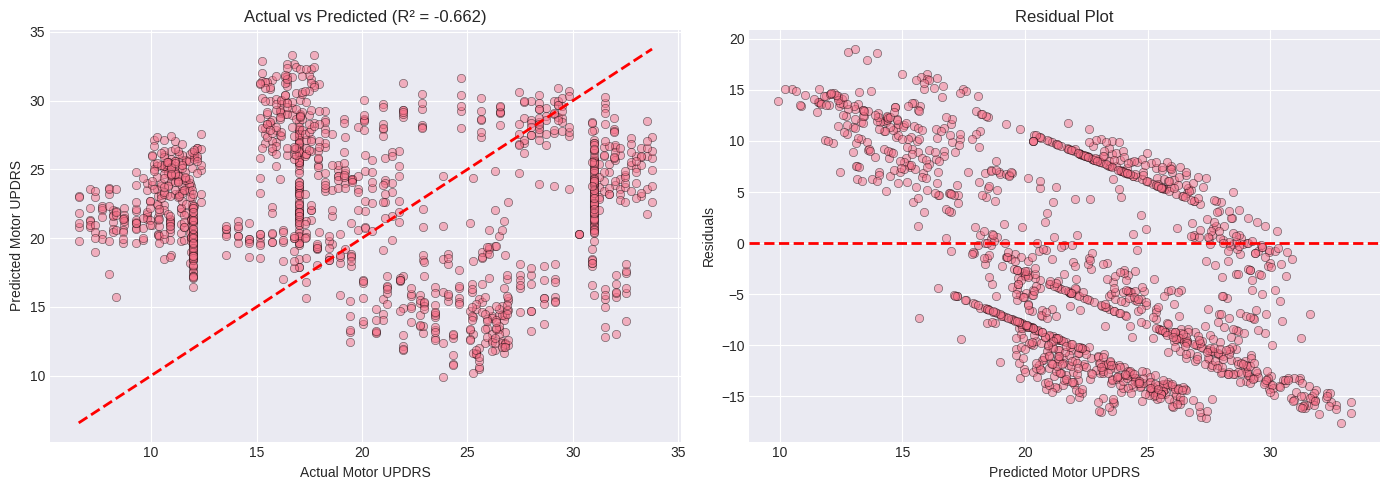

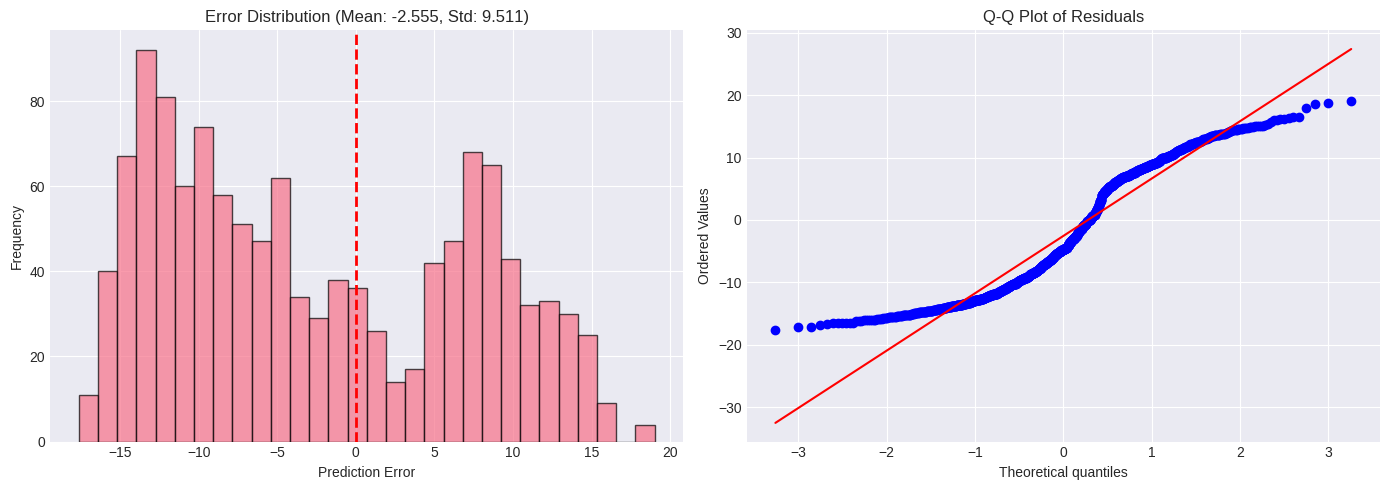

Detailed explanation available for tree-based models.


In [19]:
# Evaluate best model on test set
y_test_pred = agent.predict_with_best(X_test_scaled)

test_metrics = {
    'MSE': mean_squared_error(y_motor_test, y_test_pred),
    'MAE': mean_absolute_error(y_motor_test, y_test_pred),
    'R²': r2_score(y_motor_test, y_test_pred),
    'RMSE': np.sqrt(mean_squared_error(y_motor_test, y_test_pred))
}

print("\n" + "="*50)
print("FINAL TEST SET PERFORMANCE")
print("="*50)
print(f"Best Model: {best_name}")
print(f"Test MSE: {test_metrics['MSE']:.4f}")
print(f"Test MAE: {test_metrics['MAE']:.4f}")
print(f"Test RMSE: {test_metrics['RMSE']:.4f}")
print(f"Test R²: {test_metrics['R²']:.4f}")


# Visualization of predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_motor_test, y_test_pred, alpha=0.5, edgecolors='black', linewidth=0.5)
axes[0].plot([y_motor_test.min(), y_motor_test.max()], 
             [y_motor_test.min(), y_motor_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Motor UPDRS')
axes[0].set_ylabel('Predicted Motor UPDRS')
axes[0].set_title(f'Actual vs Predicted (R² = {test_metrics["R²"]:.3f})')

# Residual plot
residuals = y_motor_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.5, edgecolors='black', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Motor UPDRS')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()


# Error distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Prediction Error')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Error Distribution (Mean: {residuals.mean():.3f}, Std: {residuals.std():.3f})')

# Q-Q plot for residuals
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()


# Sample prediction explanation
sample_idx = X_test_scaled.index[0]
sample_explanation = agent.explain_prediction(X_test_scaled.iloc[0].values)
print(sample_explanation)


##  Multi-Task Learning for Both Targets

In [20]:
def create_multitask_model(input_dim):
    """Create a multi-task model that predicts both motor and total UPDRS"""
    inputs = layers.Input(shape=(input_dim,))
    
    # Shared layers
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    
    # Task-specific branches
    motor_branch = layers.Dense(32, activation='relu')(x)
    motor_output = layers.Dense(1, name='motor_updrs')(motor_branch)
    
    total_branch = layers.Dense(32, activation='relu')(x)
    total_output = layers.Dense(1, name='total_updrs')(total_branch)
    
    model = models.Model(inputs=inputs, outputs=[motor_output, total_output])
    return model


# Train multi-task model
multitask_model = create_multitask_model(X_train_scaled.shape[1])
multitask_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={'motor_updrs': Huber(), 'total_updrs': Huber()},
    loss_weights={'motor_updrs': 1.0, 'total_updrs': 1.0},
    metrics={'motor_updrs': ['mae'], 'total_updrs': ['mae']}
)

history_multitask = multitask_model.fit(
    X_train_scaled,
    {'motor_updrs': y_motor_train, 'total_updrs': y_total_train},
    validation_data=(X_val_scaled, 
                    {'motor_updrs': y_motor_val, 'total_updrs': y_total_val}),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


# Evaluate multi-task model
y_pred_multitask = multitask_model.predict(X_test_scaled, verbose=0)

motor_mt_metrics = {
    'MSE': mean_squared_error(y_motor_test, y_pred_multitask[0].flatten()),
    'MAE': mean_absolute_error(y_motor_test, y_pred_multitask[0].flatten()),
    'R²': r2_score(y_motor_test, y_pred_multitask[0].flatten())
}

total_mt_metrics = {
    'MSE': mean_squared_error(y_total_test, y_pred_multitask[1].flatten()),
    'MAE': mean_absolute_error(y_total_test, y_pred_multitask[1].flatten()),
    'R²': r2_score(y_total_test, y_pred_multitask[1].flatten())
}

print("Multi-Task Model Results:")
print("\nMotor UPDRS:")
print(f"  MSE: {motor_mt_metrics['MSE']:.4f}")
print(f"  MAE: {motor_mt_metrics['MAE']:.4f}")
print(f"  R²: {motor_mt_metrics['R²']:.4f}")

print("\nTotal UPDRS:")
print(f"  MSE: {total_mt_metrics['MSE']:.4f}")
print(f"  MAE: {total_mt_metrics['MAE']:.4f}")
print(f"  R²: {total_mt_metrics['R²']:.4f}")



Epoch 1/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 44.8266 - motor_updrs_loss: 17.6971 - motor_updrs_mae: 18.1953 - total_updrs_loss: 27.1289 - total_updrs_mae: 27.6287 - val_loss: 20.2041 - val_motor_updrs_loss: 7.9626 - val_motor_updrs_mae: 8.1633 - val_total_updrs_loss: 12.8378 - val_total_updrs_mae: 13.0305 - learning_rate: 0.0010
Epoch 2/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 18.0788 - motor_updrs_loss: 7.0390 - motor_updrs_mae: 7.5269 - total_updrs_loss: 11.0399 - total_updrs_mae: 11.5310 - val_loss: 15.5196 - val_motor_updrs_loss: 6.8359 - val_motor_updrs_mae: 7.0075 - val_total_updrs_loss: 9.3883 - val_total_updrs_mae: 9.4932 - learning_rate: 0.0010
Epoch 3/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 14.4107 - motor_updrs_loss: 5.9398 - motor_updrs_mae: 6.4241 - total_updrs_loss: 8.4710 - total_updrs_mae: 8.9606 - val_loss: 13.8503 - val_motor_updrs_loss: 6.4768 - val_motor_updrs_mae: 6.7130 - val_total_updrs_loss: 7.9857 - val_total_updrs_mae:

##  Summary and Conclusions


In [21]:
# Save the best model for deployment
import joblib

# Save Gradient Boosting model
joblib.dump(best_model, 'parkinsons_updrs_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(all_features, 'feature_names.pkl')

print("Models saved successfully for deployment!")
print("- parkinsons_updrs_model.pkl")
print("- feature_scaler.pkl")
print("- feature_names.pkl")

Models saved successfully for deployment!
- parkinsons_updrs_model.pkl
- feature_scaler.pkl
- feature_names.pkl
